# S&P 500 Daily - Exploratory Data Analysis

This notebook explores the S&P 500 Daily stock index dataset.

**Dataset:** `sp500-daily.csv`

**Description:** Daily S&P 500 stock index data (Spanish format) including price, open, high, low, volume, and change percentage.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = Path('../../data/raw/sp500-daily.csv')

## 1. Load and Clean Data

In [5]:
# Load dataset
df = pd.read_csv(DATA_PATH)
# Display first rows
print("First 5 rows (raw):")
display(df.head())
# Clean column names (Spanish to English)
df.columns = ['Date', 'Last', 'Open', 'High', 'Low', 'Vol.', 'Change %']
# Parse date (format: DD.MM.YYYY)
df['Date'] = pd.to_datetime(df['Date'], format='%d.%m.%Y')
# Clean numeric columns (Spanish format: comma as decimal separator, dot as thousands)
numeric_cols = ['Last', 'Open', 'High', 'Low']
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
# Clean Volume column (handles K, M, B suffixes)
def clean_volume(v):
    if pd.isna(v) or v == '' or v == '-':
        return np.nan
    v = str(v).replace('.', '').replace(',', '.').upper()
    if 'K' in v:
        return float(v.replace('K', '')) * 1e3
    if 'M' in v:
        return float(v.replace('M', '')) * 1e6
    if 'B' in v:
        return float(v.replace('B', '')) * 1e9
    try:
        return float(v)
    except:
        return np.nan
if 'Vol.' in df.columns:
    df['Vol.'] = df['Vol.'].apply(clean_volume)
# Clean percentage column
df['Change %'] = df['Change %'].str.replace('%', '').str.replace(',', '.').astype(float)
# Sort by date
df = df.sort_values('Date').reset_index(drop=True)
print("\nCleaned dataset:")
display(df.head())
print("\nData types:")
print(df.dtypes)


First 5 rows (raw):


,Fecha,Último,Apertura,Máximo,Mínimo,Vol.,% var.
0,13.11.2023,"4.411,55","4.406,66","4.421,76","4.393,82",NaN,"-0,08%"
1,10.11.2023,"4.415,24","4.364,15","4.418,03","4.353,34",NaN,"1,56%"
2,09.11.2023,"4.347,35","4.391,41","4.393,40","4.343,94",NaN,"-0,81%"
3,08.11.2023,"4.382,78","4.384,37","4.391,20","4.359,76",NaN,"0,10%"
4,07.11.2023,"4.378,38","4.366,21","4.386,26","4.355,41",NaN,"0,28%"



Cleaned dataset:


,Date,Last,Open,High,Low,Vol.,Change %
0,2004-01-05,1122.2,1108.5,1122.2,1108.5,NaN,1.24
1,2004-01-06,1123.7,1122.2,1124.5,1118.4,NaN,0.13
2,2004-01-07,1126.3,1123.7,1126.3,1116.5,NaN,0.23
3,2004-01-08,1131.9,1126.3,1131.9,1124.9,NaN,0.50
4,2004-01-09,1121.9,1131.9,1131.9,1120.9,NaN,-0.88



Data types:
Date        datetime64[ns]
Last               float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %           float64
dtype: object


## 2. Data Overview

In [6]:
print("Dataset Shape:", df.shape)
print("\nDate range:", df['Date'].min(), "to", df['Date'].max())
print("Total trading days:", len(df))
print("\nDataset Info:")
df.info()

Dataset Shape: (5000, 7)

Date range: 2004-01-05 00:00:00 to 2023-11-13 00:00:00
Total trading days: 5000

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      5000 non-null   datetime64[ns]
 1   Last      5000 non-null   float64       
 2   Open      5000 non-null   float64       
 3   High      5000 non-null   float64       
 4   Low       5000 non-null   float64       
 5   Vol.      0 non-null      float64       
 6   Change %  5000 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 273.6 KB


## 3. Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print("Missing Values Summary:")
display(missing_df[missing_df['Missing Count'] > 0])
if missing.sum() == 0:
    print("\n✓ No missing values found!")

Missing Values Summary:


,Missing Count,Percentage
Vol.,5000,100.0


## 4. Descriptive Statistics

In [8]:
print("Descriptive Statistics:")
display(df[['Last', 'Open', 'High', 'Low', 'Change %']].describe())

Descriptive Statistics:


,Last,Open,High,Low,Change %
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2123.153178,2122.788608,2134.849860,2109.899418,0.034932
std,1070.538688,1070.431274,1076.234089,1064.202559,1.207534
min,676.500000,679.300000,695.300000,666.800000,-11.980000
25%,1266.550000,1266.150000,1274.075000,1259.575000,-0.420000
50%,1790.450000,1789.900000,1796.600000,1779.300000,0.070000
75%,2782.625000,2783.125000,2794.125000,2764.975000,0.570000
max,4796.600000,4804.500000,4818.600000,4780.000000,11.590000


## 5. Price Time Series

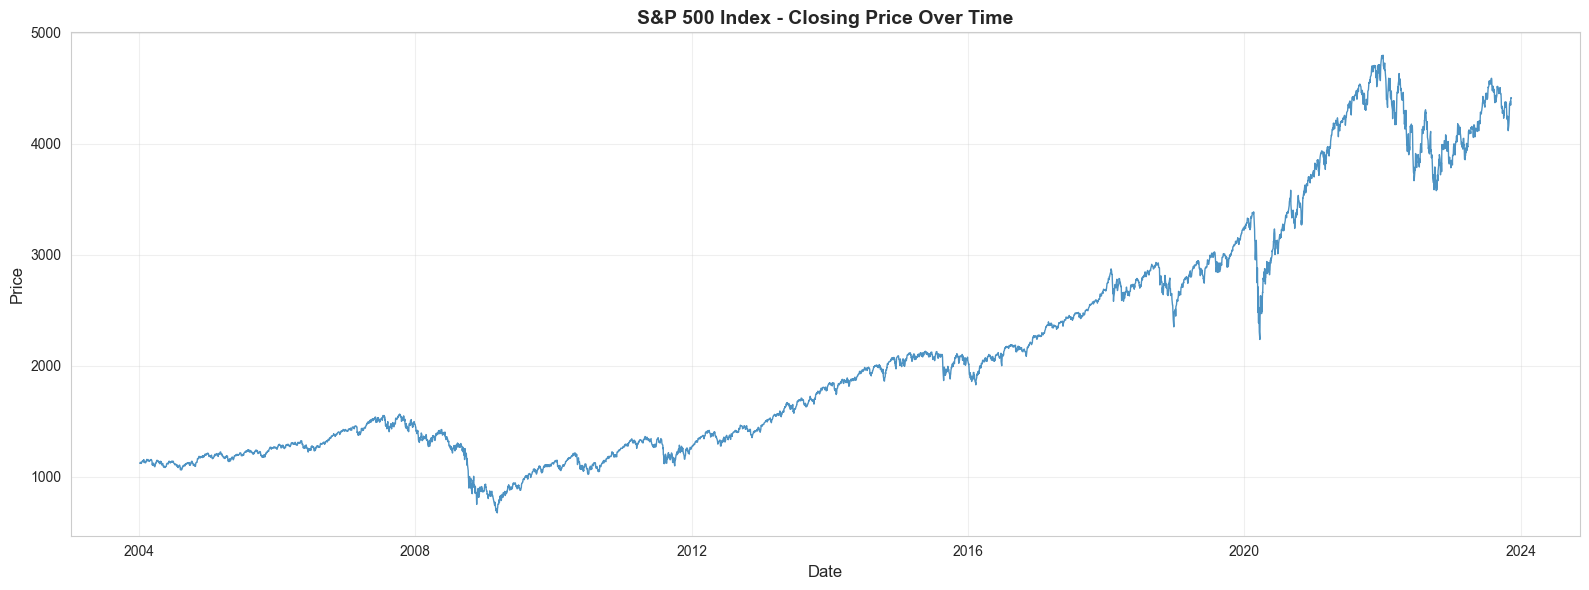

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Last'], linewidth=1, alpha=0.8)
ax.set_title('S&P 500 Index - Closing Price Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

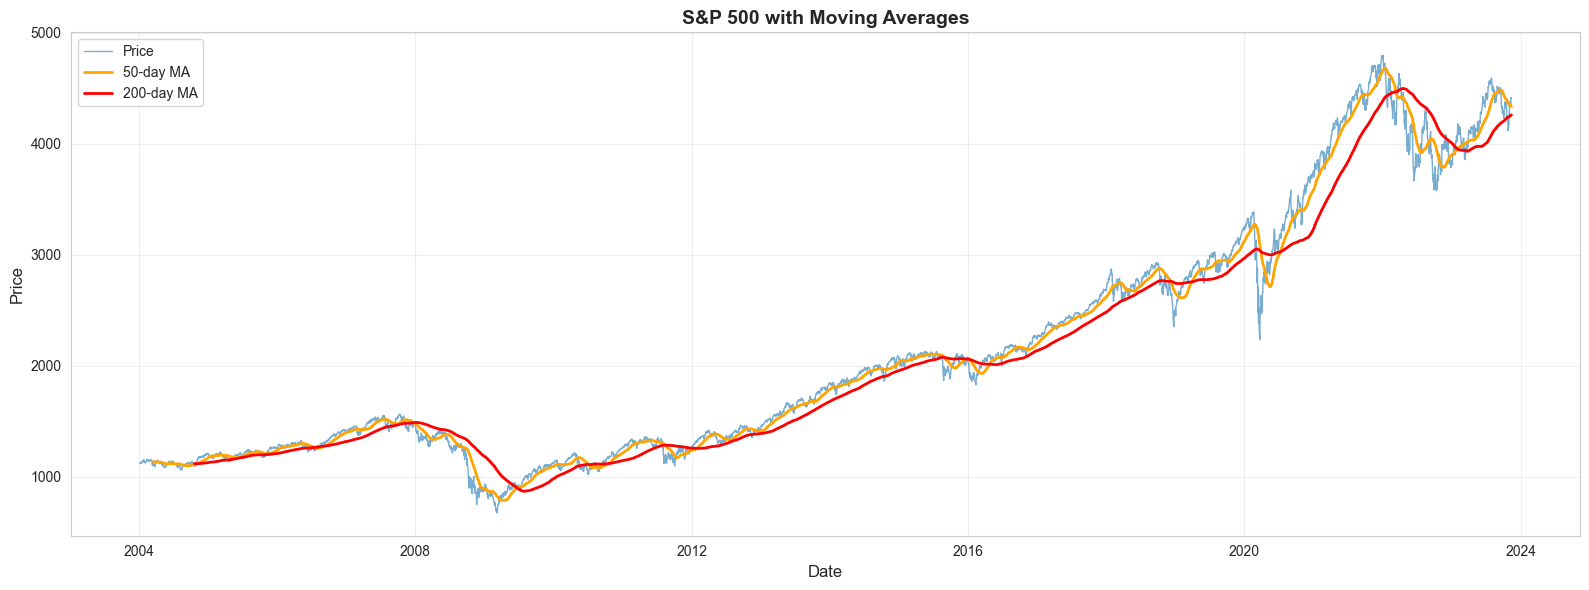

In [10]:
# Moving averages
df['MA_50'] = df['Last'].rolling(window=50).mean()
df['MA_200'] = df['Last'].rolling(window=200).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Last'], linewidth=1, alpha=0.6, label='Price')
ax.plot(df['Date'], df['MA_50'], linewidth=2, label='50-day MA', color='orange')
ax.plot(df['Date'], df['MA_200'], linewidth=2, label='200-day MA', color='red')
ax.set_title('S&P 500 with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Returns Analysis

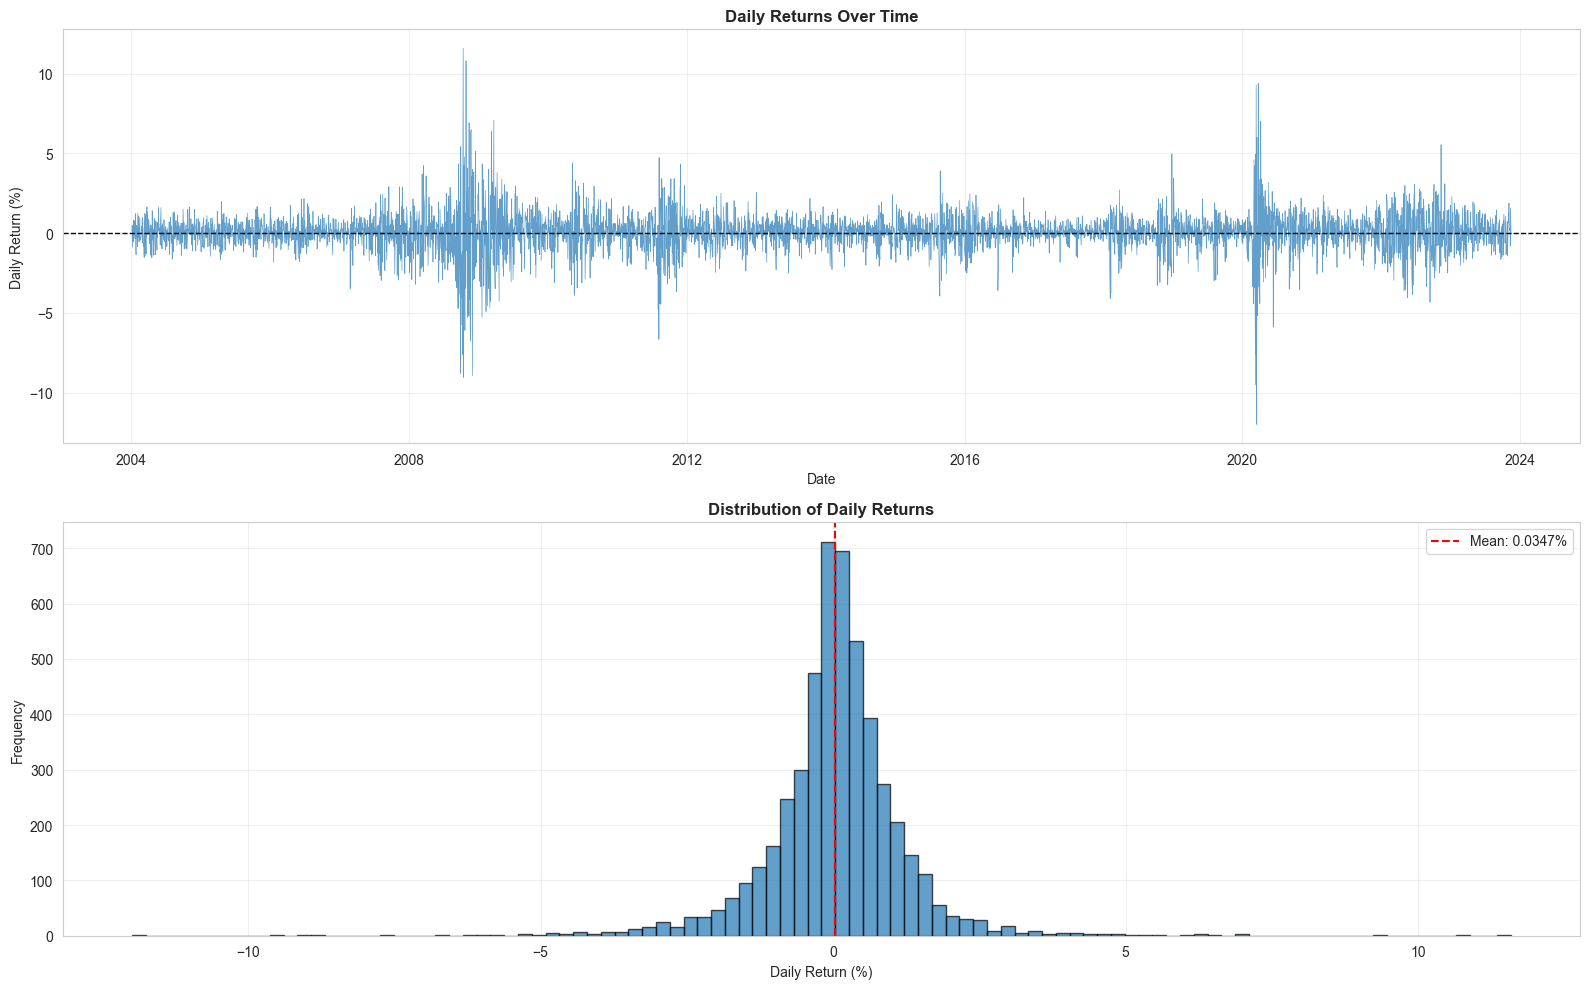

In [11]:
df['Daily_Return'] = df['Last'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(df['Date'], df['Daily_Return'], linewidth=0.5, alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Daily Returns Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Daily Return (%)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['Daily_Return'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label=f'Mean: {df["Daily_Return"].mean():.4f}%')
axes[1].set_title('Distribution of Daily Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Volatility Analysis

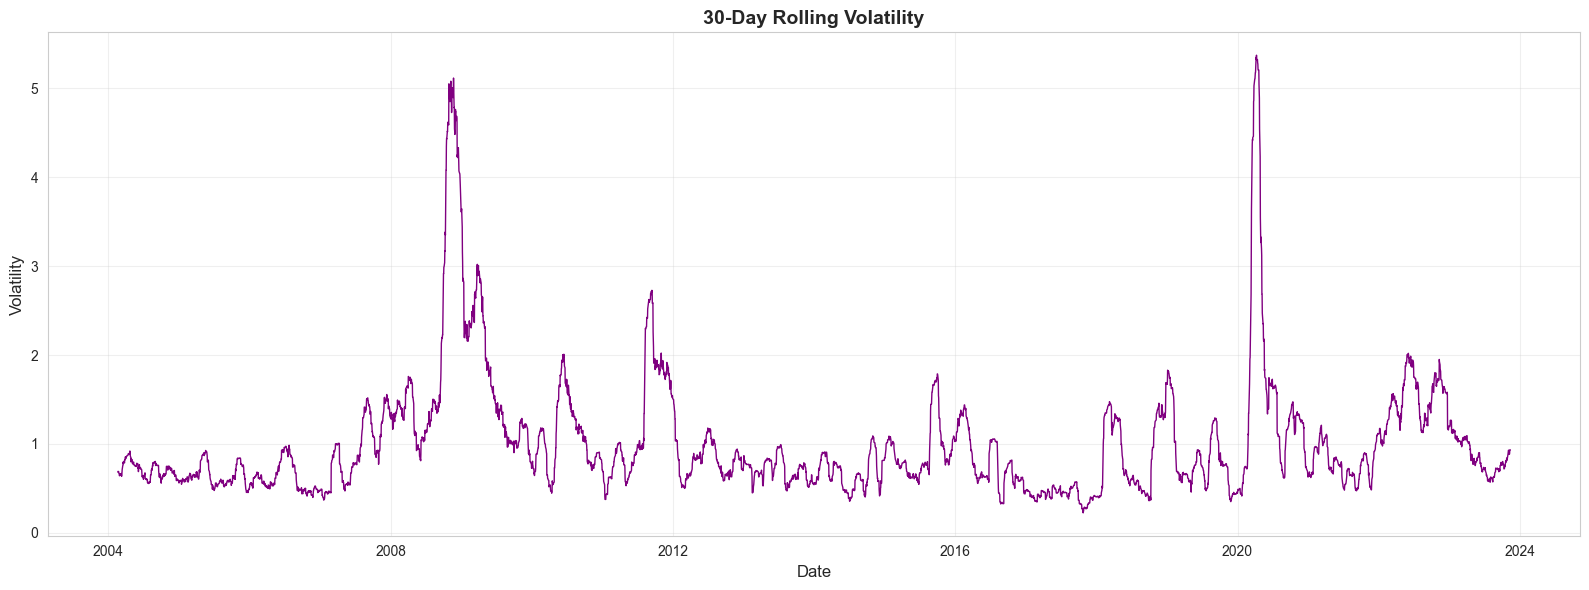

In [12]:
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df['Date'], df['Volatility_30d'], linewidth=1, color='purple')
ax.set_title('30-Day Rolling Volatility', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary

In [13]:
print("=" * 60)
print("KEY FINDINGS - S&P 500 DAILY")
print("=" * 60)
print(f"\n1. Dataset Coverage:")
print(f"   - Start: {df['Date'].min().strftime('%Y-%m-%d')}")
print(f"   - End: {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"   - Days: {len(df):,}")
print(f"\n2. Price Statistics:")
print(f"   - Current: {df['Last'].iloc[-1]:.2f}")
print(f"   - All-time High: {df['Last'].max():.2f}")
print(f"   - All-time Low: {df['Last'].min():.2f}")
print(f"\n3. Returns:")
print(f"   - Avg Daily Return: {df['Daily_Return'].mean():.4f}%")
print(f"   - Volatility: {df['Daily_Return'].std():.4f}%")
print(f"   - Best Day: {df['Daily_Return'].max():.2f}%")
print(f"   - Worst Day: {df['Daily_Return'].min():.2f}%")
print("\n" + "=" * 60)

KEY FINDINGS - S&P 500 DAILY

1. Dataset Coverage:
   - Start: 2004-01-05
   - End: 2023-11-13
   - Days: 5,000

2. Price Statistics:
   - Current: 4411.55
   - All-time High: 4796.60
   - All-time Low: 676.50

3. Returns:
   - Avg Daily Return: 0.0347%
   - Volatility: 1.2075%
   - Best Day: 11.59%
   - Worst Day: -11.98%

